### Name : Vaishali Taywade
### Section : B
### Batch : B4
### Roll no. : 61
### practical no 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
df = pd.read_csv('USA_HOUSING.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
pd.set_option('display.float_format','{:.2f}'.format)

In [ ]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,68583.11,5.98,6.99,3.98,36163.52,1232072.65
std,10657.99,0.99,1.01,1.23,9925.65,353117.63
min,17796.63,2.64,3.24,2.00,172.61,15938.66
25%,61480.56,5.32,6.30,3.14,29403.93,997577.14
50%,68804.29,5.97,7.00,4.05,36199.41,1232669.38
75%,75783.34,6.65,7.67,4.49,42861.29,1471210.20
max,107701.75,9.52,10.76,6.50,69621.71,2469065.59


In [ ]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.94,7.83,6.14,3.46,22837.36,1060193.79,USNS Williams\nFPO AP 30153-7653
4996,78491.28,7.00,6.58,4.02,25616.12,1482617.73,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.69,7.25,4.81,2.13,33266.15,1030729.58,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.33,5.53,7.13,5.44,42625.62,1198656.87,USS Wallace\nFPO AE 73316
4999,65510.58,5.99,6.79,4.07,46501.28,1298950.48,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [ ]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [ ]:
df.drop("Address",axis=1,inplace=True)

In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


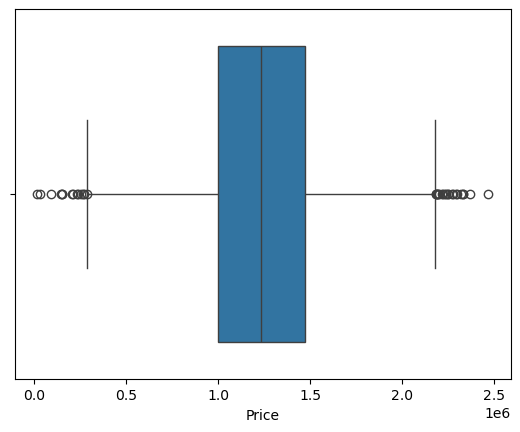

In [ ]:
sns.boxplot(x=df["Price"])
plt.show()

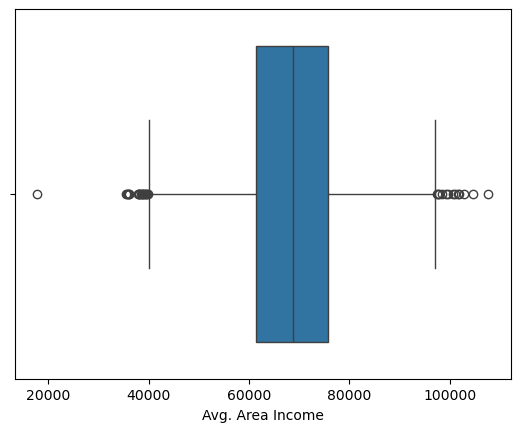

In [ ]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

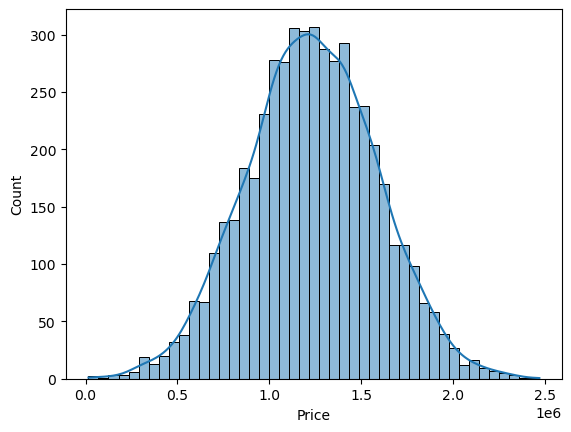

In [ ]:
sns.histplot(df["Price"],kde=True)
plt.show

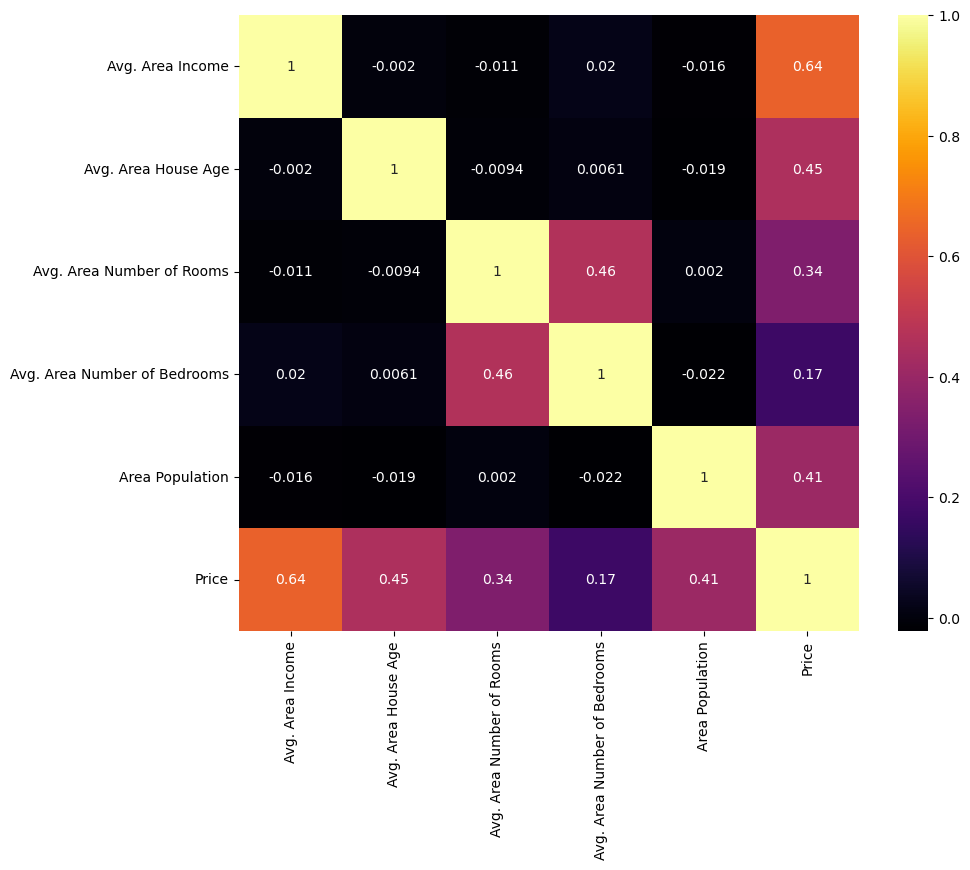

In [ ]:
plt.figure(figsize=(10,8))

numeric_df =df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='inferno')
plt.show()

In [ ]:
X = df[['Avg. Area Income']]
y=df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
slr_model = LinearRegression()
slr_model.fit(X_train,y_train)

LinearRegression()

In [ ]:
#Standard Scaling
#from sklearn.preprocessing import StandardScaler
#scaler=StandardScaler()
#X[["Avg. Area Income","Price"]] = scaler.fit_transform(X[["Avg. Area Income","Area Population"]])

In [ ]:
y_pred = slr_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
print("Simple Linear Regression Results")
print("--------------------------------")

print("MAE :", mean_absolute_error(y_test,y_pred))
print("MSE :", mean_squared_error(y_test,y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE :", r2_score(y_test,y_pred))

Simple Linear Regression Results
--------------------------------
MAE : 216826.3530998906
MSE : 74194887058.66
RMSE : 272387.38417676394
MAE : 0.39694865192619766


In [ ]:
print("Intercept :", slr_model.intercept_)
print("Slope:",slr_model.coef_[0])

Intercept : -225053.70287170215
Slope: 21.208906292657524


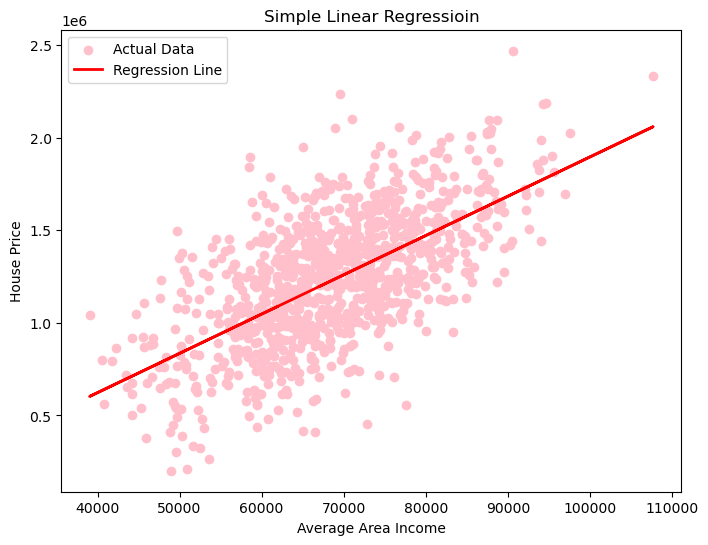

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_test,y_test,color='pink', label='Actual Data')

plt.plot(X_test,y_pred,color='red',linewidth=2,label='Regression Line')

plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regressioin")
plt.legend()

plt.show()

In [ ]:
income = float(input("Enter Average Area Income: "))
new_data = np.array([[income]])
prediction = slr_model.predict(new_data)
print("Predicted House Price = ${:,.2f}".format(prediction[0]))

Enter Average Area Income:  4657657


Predicted House Price = $98,558,757.15


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Multiple Linear Regression

In [ ]:
#Simple linear regression
#Multiple linear regression
#Hyperparameter tuning

In [ ]:
X = df.drop(["Price"],axis=1)
y=df["Price"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)

LinearRegression()

In [ ]:
coef = pd.DataFrame(
    mlr.coef_,
    X.columns,
    columns=["Coefficient"])
coef

,Coefficient
Avg. Area Income,21.65
Avg. Area House Age,164666.48
Avg. Area Number of Rooms,119624.01
Avg. Area Number of Bedrooms,2440.38
Area Population,15.27


In [ ]:
y_pred=mlr.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test,y_pred))
print("MSE :",mean_squared_error(y_test,y_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R^2 :",r2_score(y_test,y_pred))

MAE : 80879.09723487173
MSE : 10089009300.890953
RMSE : 100444.0605555697
R^2 : 0.9179971706834579


In [ ]:
predictions = mlr.predict(X_test)

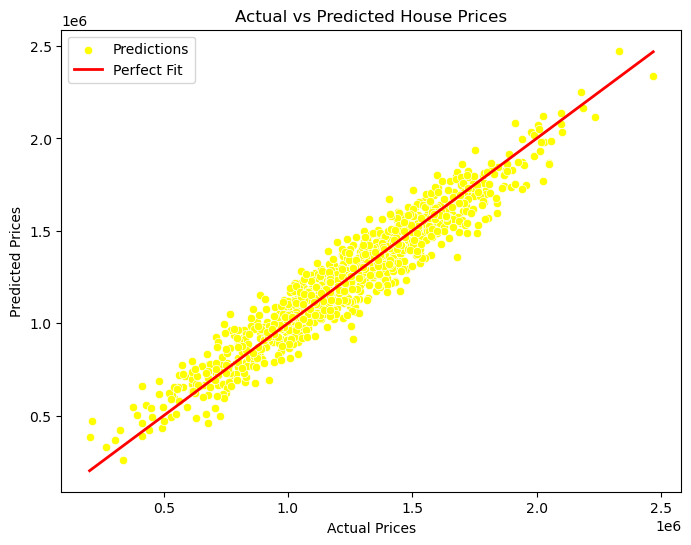

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=predictions,color='yellow', label='Predictions')

plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linewidth=2,label='Perfect Fit')

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

### Hyperparameter Tuning

### Ridge Regression

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Default Ridge R^2 :",r2_score(y_test, ridge_pred))

Default Ridge R^2 : 0.3969486519262033


In [ ]:
param_grid = {'alpha':[0.001,0.01,0.1,1,10,100]}

In [ ]:
grid_ridge = GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring='r2',cv=5)

In [ ]:
grid_ridge.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [ ]:
print("Best Alpha :",grid_ridge.best_params_)

Best Alpha : {'alpha': 100}


In [ ]:
print(grid_ridge.best_score_)

0.41110861933657433


In [ ]:
best_ridge = grid_ridge.best_estimator_
ridge_pred = best_ridge.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test,ridge_pred))
print("MSE :",mean_squared_error(y_test,ridge_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,ridge_pred)))
print("R^2 :",r2_score(y_test,ridge_pred))

MAE : 216826.35310007748
MSE : 74194887058.58911
RMSE : 272387.38417663384
R^2 : 0.39694865192677387


### Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
param_grid = {'alpha':[0.001,0.01,0.1,1,10]}

In [ ]:
grid_lasso = GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')
grid_lasso.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [ ]:
print(grid_lasso.best_params_)

{'alpha': 10}


In [ ]:
lasso_pred = grid_lasso.predict(X_test)
print(r2_score(y_test,lasso_pred))

0.39694865193706386


In [ ]:
# Dont write multiple regression code from here

In [ ]:
income=float(input("Enter Average Area Income: "))
house_age = float(input("Enter Average Area House Age: "))
rooms = float(input("Enter Average Area Number of Rooms: "))
bedrooms = float(input("Enter Average Area Number of Bedrooms: "))
population = float(input("Enter Area Population: "))

test_input = np.array([[income,house_age,rooms,bedrooms,population]])

predicted_price=mlr.predict(test_input)

print("\nPredicted House Price: ${:,.2f}".format(predicted_price[0]))


Enter Average Area Income:  354667
Enter Average Area House Age:  5
Enter Average Area Number of Rooms:  8
Enter Average Area Number of Bedrooms:  4
Enter Area Population:  150



Predicted House Price: $6,836,626.52


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
